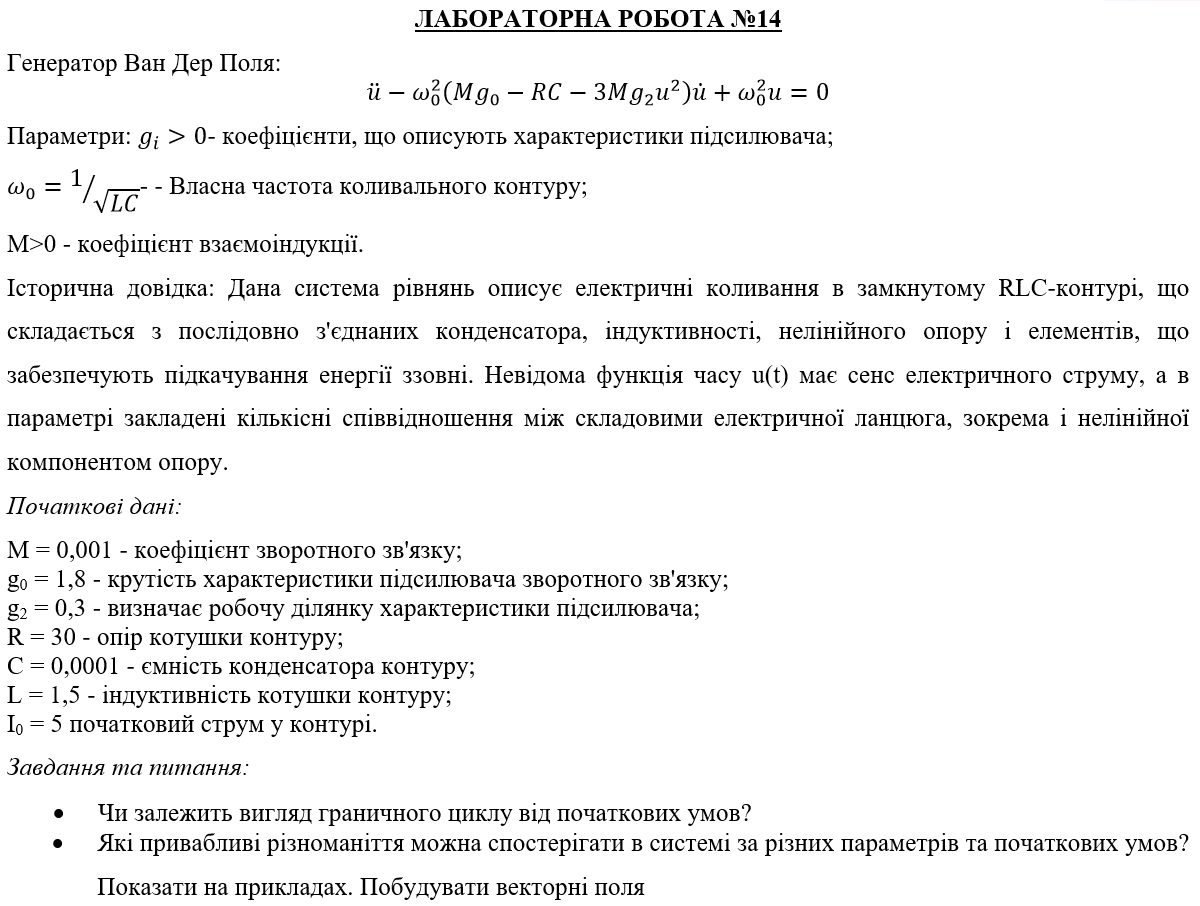

Власна частота w0 = 81.65 рад/с
R = 30 Ом. Mg0 - RC = -0.00120. Режим: Згасання
R = 10 Ом. Mg0 - RC = 0.00080. Режим: Генерація


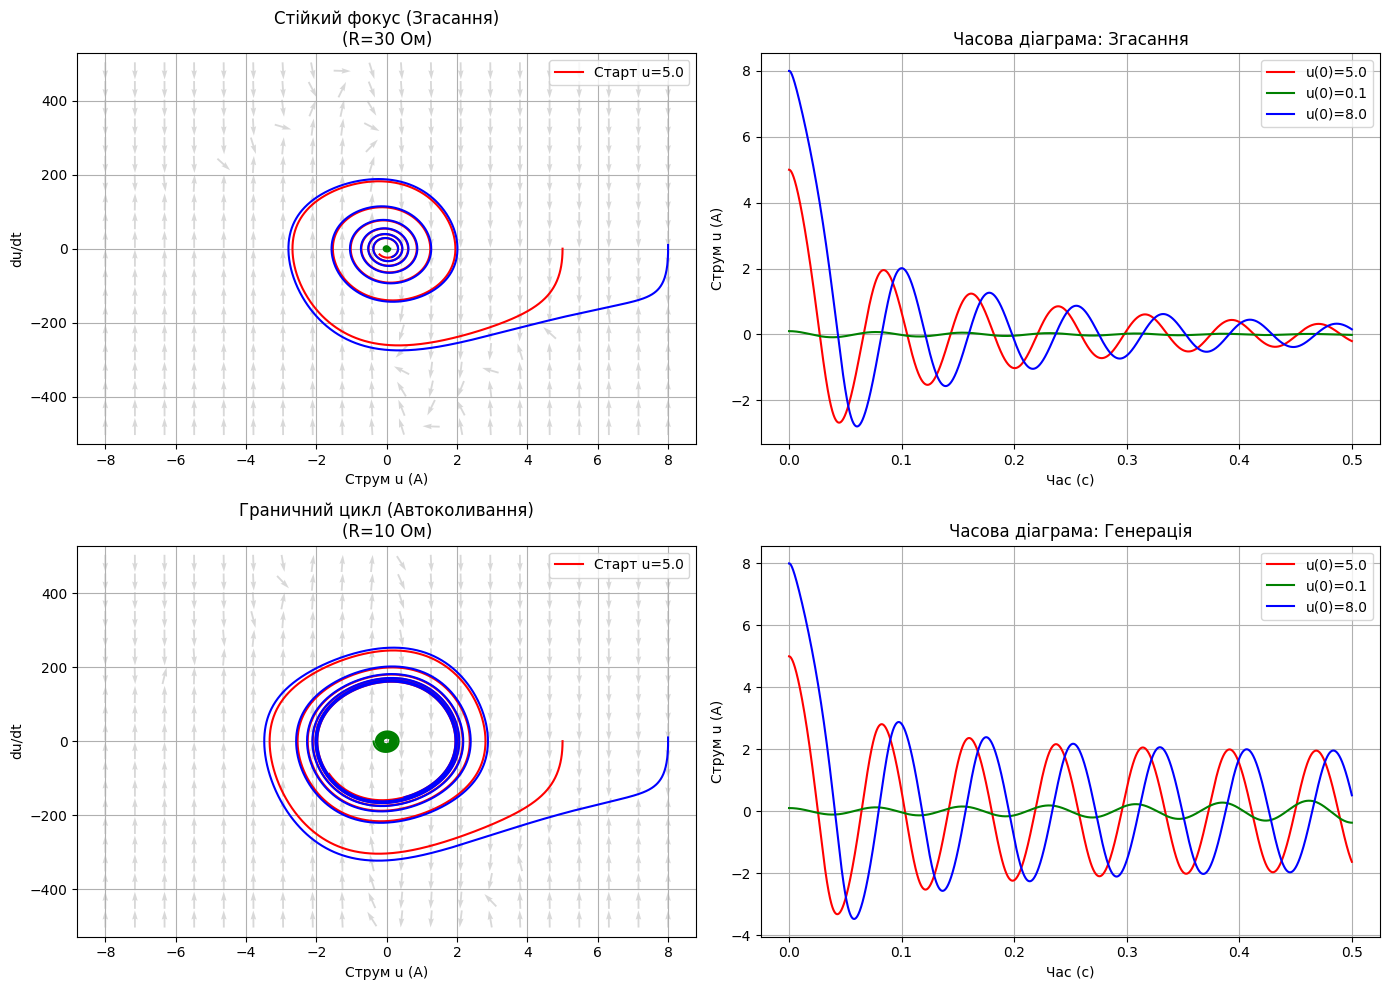

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Параметри системи
params = {
    'M': 0.001,
    'g0': 1.8,
    'g2': 0.3,
    'C': 0.0001,
    'L': 1.5
}

# Розрахунок частоти omega0
LC = params['L'] * params['C']
omega0_sq = 1 / LC
omega0 = np.sqrt(omega0_sq)

print(f"Власна частота w0 = {omega0:.2f} рад/с")

# Рівняння Ван дер Поля
def vdp_system(t, state, R, M, g0, g2, w0_sq):
    u, u_dot = state # u - струм, u_dot - швидкість зміни струму

    damping_term = (M * g0 - R * params['C'] - 3 * M * g2 * (u**2))

    du = u_dot
    du_dot = w0_sq * damping_term * u_dot - w0_sq * u

    return [du, du_dot]

# Функція для побудови графіків
def analyze_case(R_val, title_text, ax_phase, ax_time):
    bracket = params['M'] * params['g0'] - R_val * params['C']
    regime = "Генерація" if bracket > 0 else "Згасання"
    print(f"R = {R_val} Ом. Mg0 - RC = {bracket:.5f}. Режим: {regime}")

    # Моделювання для різних початкових умов
    initial_conditions = [
        [5.0, 0.0],    # Задане в умові I0=5
        [0.1, 0.0],    # Малий сигнал
        [8.0, 10.0]    # Великий сигнал
    ]

    colors = ['r', 'g', 'b']

    # Інтегрування
    t_span = (0, 0.5)
    t_eval = np.linspace(0, 0.5, 5000)

    for i, ic in enumerate(initial_conditions):
        sol = solve_ivp(vdp_system, t_span, ic,
                        args=(R_val, params['M'], params['g0'], params['g2'], omega0_sq),
                        t_eval=t_eval, rtol=1e-9, atol=1e-9)

        # Фазовий портрет
        lbl = f'Старт u={ic[0]}' if i==0 else None
        ax_phase.plot(sol.y[0], sol.y[1], color=colors[i], label=lbl, linewidth=1.5)

        # Часова діаграма (тільки для u)
        ax_time.plot(sol.t, sol.y[0], color=colors[i], label=f'u(0)={ic[0]}')

    # Побудова векторного поля
    lim = 8
    u_vals = np.linspace(-lim, lim, 20)
    udot_vals = np.linspace(-lim*60, lim*60, 20)
    U, V = np.meshgrid(u_vals, udot_vals)

    dU = V
    Term = (params['M']*params['g0'] - R_val*params['C'] - 3*params['M']*params['g2']*(U**2))
    dV = omega0_sq * Term * V - omega0_sq * U

    # Нормалізація стрілок
    N = np.sqrt(dU**2 + dV**2)
    N[N==0] = 1

    ax_phase.quiver(U, V, dU/N, dV/N, color='gray', alpha=0.3, pivot='mid')

    # Оформлення
    ax_phase.set_title(f"{title_text}\n(R={R_val} Ом)")
    ax_phase.set_xlabel('Струм u (А)')
    ax_phase.set_ylabel('du/dt')
    ax_phase.grid(True)
    ax_phase.legend()

    ax_time.set_title(f"Часова діаграма: {regime}")
    ax_time.set_xlabel('Час (с)')
    ax_time.set_ylabel('Струм u (А)')
    ax_time.grid(True)
    ax_time.legend()

# Головна частина
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Випадок 1: Вхідні дані (R=30) -> Згасання
analyze_case(30, "Стійкий фокус (Згасання)", axes[0, 0], axes[0, 1])

# Випадок 2: Модифіковані дані (R=10) -> Граничний цикл
analyze_case(10, "Граничний цикл (Автоколивання)", axes[1, 0], axes[1, 1])

plt.tight_layout()
plt.show()